In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('Datasets/placement.csv')

In [3]:
data

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [4]:
data.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


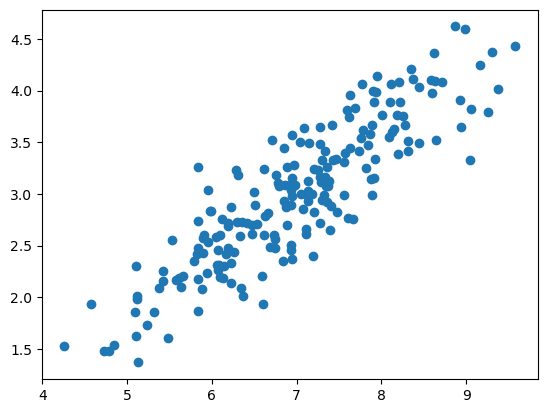

In [5]:
plt.scatter(data['cgpa'],data['package'])

In [6]:
X = data.iloc[:,0:1].values
y = data.iloc[:,-1].values

In [7]:
X,y

(array([[6.89],
        [5.12],
        [7.82],
        [7.42],
        [6.94],
        [7.89],
        [6.73],
        [6.75],
        [6.09],
        [8.31],
        [5.32],
        [6.61],
        [8.94],
        [6.93],
        [7.73],
        [7.25],
        [6.84],
        [5.38],
        [6.94],
        [7.48],
        [7.28],
        [6.85],
        [6.14],
        [6.19],
        [6.53],
        [7.28],
        [8.31],
        [5.42],
        [5.94],
        [7.15],
        [7.36],
        [8.1 ],
        [6.96],
        [6.35],
        [7.34],
        [6.87],
        [5.99],
        [5.9 ],
        [8.62],
        [7.43],
        [9.38],
        [6.89],
        [5.95],
        [7.66],
        [5.09],
        [7.87],
        [6.07],
        [5.84],
        [8.63],
        [8.87],
        [9.58],
        [9.26],
        [8.37],
        [6.47],
        [6.86],
        [8.2 ],
        [5.84],
        [6.6 ],
        [6.92],
        [7.56],
        [5.61],
        [5.48],
        

In [8]:
X.mean()

6.990500000000001

### Linear Regression from scratch

In [9]:
class SimpleLinearReg:

    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, X, y):
        num=0
        den=0
        for i in range(X.shape[0]):
            num = num+(X[i]-X.mean())*(y[i]-y.mean())
            den= den+((X[i]-X.mean())*(X[i]-X.mean()))
        self.m = num/den
        self.b = y.mean()-(self.m*X.mean())
        print(self.m)
        print(self.b)

    def predict(self, X_test):
        return self.m * (X_test+self.b)

In [10]:
obj = SimpleLinearReg()

In [11]:
obj.fit(X,y)

[0.56959129]
[-0.98567795]


In [12]:
x_test = obj.predict(8.58)

In [13]:
x_test

array([4.32565973])

### everytime u change your class(like any function or any changes inside class) you must create object again

- Problem with this is you can only run simple regression

## Multiple Linear Regression

In [15]:
from sklearn.datasets import load_diabetes

In [33]:
X,y = load_diabetes(return_X_y=True)

In [34]:
X

array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
         0.01990749, -0.01764613],
       [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
        -0.06833155, -0.09220405],
       [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
         0.00286131, -0.02593034],
       ...,
       [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
        -0.04688253,  0.01549073],
       [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
         0.04452873, -0.02593034],
       [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
        -0.00422151,  0.00306441]])

In [35]:
X.shape

(442, 10)

In [36]:
# Train test split
from sklearn.model_selection import train_test_split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=2)

In [38]:
print(X_train.shape)

(353, 10)


In [39]:
print(X_test.shape)

(89, 10)


In [40]:
# model
from sklearn.linear_model import LinearRegression

In [41]:
lr = LinearRegression()

In [42]:
lr.fit(X_train,y_train)

LinearRegression()

In [43]:
y_pred = lr.predict(X_test)

In [44]:
y_pred

array([154.1213881 , 204.81835118, 124.93755353, 106.08950893,
       258.5348576 , 256.3310074 , 118.75087616, 119.52440696,
       101.50816735, 190.54048661, 141.70656811, 172.51883961,
       174.33861649, 134.80942706, 294.13994537,  94.11798038,
       211.97059795, 156.49579378, 134.21000428, 119.62664644,
       148.87842251, 165.00873409, 151.10021038, 176.04063756,
       133.27769647, 221.29555392, 197.17324941,  96.1577688 ,
        50.26012711, 230.48580317, 242.06073866, 114.11129218,
        67.07532417,  94.52943825, 201.21415375, 167.05136201,
       159.881268  , 192.78746659, 114.49551325, 233.48234551,
       140.82563045, 121.0680409 , 192.27480772, 191.12738845,
       179.16865788, 148.34935601, 163.47414622, 276.81647884,
       100.17926432, 164.10555298, 255.80762189, 136.9466204 ,
       152.37503699, 107.92237882, 194.21924678,  77.34670792,
       118.50482479,  68.38335763, 154.29258529, 162.48840259,
       168.36788326, 156.87790322,  97.14191797, 238.16

In [45]:
from sklearn.metrics import r2_score

In [46]:
r2_score(y_test,y_pred)

0.4399338661568969

In [47]:
lr.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

## Make our own Multi LR

In [63]:
class MultiLR:

    def __init__(self):
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X_train, y_train):
        X_train = np.insert(X_train,0,1,axis=1)
        #calculate coef
        betas = np.linalg.inv(np.dot(X_train.T,X_train)).dot(X_train.T).dot(y_train)
        self.intercept_ = betas[0]
        self.coef_ = betas[1:]

    def predict(self, X_test):
        return (self.intercept_ + np.dot(X_test, self.coef_))

In [64]:
mlr = MultiLR()

In [65]:
mlr.fit(X_train, y_train)

In [66]:
y_pred_mlr = mlr.predict(X_test)

In [67]:
y_pred_mlr

array([154.1213881 , 204.81835118, 124.93755353, 106.08950893,
       258.5348576 , 256.3310074 , 118.75087616, 119.52440696,
       101.50816735, 190.54048661, 141.70656811, 172.51883961,
       174.33861649, 134.80942706, 294.13994537,  94.11798038,
       211.97059795, 156.49579378, 134.21000428, 119.62664644,
       148.87842251, 165.00873409, 151.10021038, 176.04063756,
       133.27769647, 221.29555392, 197.17324941,  96.1577688 ,
        50.26012711, 230.48580317, 242.06073866, 114.11129218,
        67.07532417,  94.52943825, 201.21415375, 167.05136201,
       159.881268  , 192.78746659, 114.49551325, 233.48234551,
       140.82563045, 121.0680409 , 192.27480772, 191.12738845,
       179.16865788, 148.34935601, 163.47414622, 276.81647884,
       100.17926432, 164.10555298, 255.80762189, 136.9466204 ,
       152.37503699, 107.92237882, 194.21924678,  77.34670792,
       118.50482479,  68.38335763, 154.29258529, 162.48840259,
       168.36788326, 156.87790322,  97.14191797, 238.16

In [68]:
y_pred_mlr.shape

(89,)

In [70]:
r2_score(y_test, y_pred_mlr)

0.439933866156897

In [71]:
mlr.coef_

array([  -9.15865318, -205.45432163,  516.69374454,  340.61999905,
       -895.5520019 ,  561.22067904,  153.89310954,  126.73139688,
        861.12700152,   52.42112238])

In [72]:
mlr.intercept_

151.88331005254167

In [74]:
data = pd.read_csv('Datasets/placement.csv')

In [87]:
data['cgpa'].values.reshape(-1, 1)

array([[6.89],
       [5.12],
       [7.82],
       [7.42],
       [6.94],
       [7.89],
       [6.73],
       [6.75],
       [6.09],
       [8.31],
       [5.32],
       [6.61],
       [8.94],
       [6.93],
       [7.73],
       [7.25],
       [6.84],
       [5.38],
       [6.94],
       [7.48],
       [7.28],
       [6.85],
       [6.14],
       [6.19],
       [6.53],
       [7.28],
       [8.31],
       [5.42],
       [5.94],
       [7.15],
       [7.36],
       [8.1 ],
       [6.96],
       [6.35],
       [7.34],
       [6.87],
       [5.99],
       [5.9 ],
       [8.62],
       [7.43],
       [9.38],
       [6.89],
       [5.95],
       [7.66],
       [5.09],
       [7.87],
       [6.07],
       [5.84],
       [8.63],
       [8.87],
       [9.58],
       [9.26],
       [8.37],
       [6.47],
       [6.86],
       [8.2 ],
       [5.84],
       [6.6 ],
       [6.92],
       [7.56],
       [5.61],
       [5.48],
       [6.34],
       [9.16],
       [7.36],
       [7.6 ],
       [5.

In [88]:
X_train, X_test, y_train, y_test = train_test_split(data['cgpa'].values.reshape(-1, 1),data['package'].values.reshape(-1, 1),test_size=0.2, random_state=2)

In [89]:
X_train.shape

(160, 1)

In [90]:
X_test.shape

(40, 1)

In [91]:
mlr.fit(X_train,y_train)

In [92]:
y_pred_data = mlr.predict(X_test)

In [93]:
y_pred_data

array([[3.89111601],
       [3.09324469],
       [2.38464568],
       [2.57434935],
       [1.6537286 ],
       [1.77647803],
       [2.07219258],
       [2.93143862],
       [3.76278706],
       [2.93701814],
       [4.09197872],
       [3.51170867],
       [2.97049525],
       [2.40138424],
       [3.18809652],
       [3.46707251],
       [1.94386362],
       [3.24389172],
       [2.97607477],
       [3.41685683],
       [2.55761079],
       [3.16577844],
       [2.85890486],
       [3.12114229],
       [3.68467378],
       [2.8700639 ],
       [3.49497011],
       [3.34432308],
       [3.91901361],
       [1.96060218],
       [3.65119666],
       [3.2104146 ],
       [3.74046898],
       [2.7863711 ],
       [2.78079158],
       [3.27178932],
       [3.52844723],
       [2.61340599],
       [2.65804215],
       [2.71383735]])

In [94]:
r2_score(y_test,y_pred_data)

0.7807301475103854